In [41]:
import numpy as np
from scipy.special import softmax
import pandas as pd
import seaborn as sns
import pylab as pl
from scipy.optimize import minimize, differential_evolution
import belief_mix_model as bmm
from scipy.spatial.distance import cdist,pdist,euclidean
from collections import Counter
import scipy as sp
from matplotlib.patches import Ellipse

In [42]:
data_dir = "../Lucas_Cecile/"
fig_dir = "./figures/brinkman_board/"

In [43]:
processed_data = pd.read_csv(data_dir+"extracted_trajs.csv")


In [44]:
# ps = "with_beta_wo_effort"
# ps = "with_beta_wo_effort_wo_random"
ps = "with_beta_wo_effort_wo_random_wo_sigma_K_curr_loc"
# ps = "with_beta_wo_effort_wo_random_wo_sigma_with_mixture_spatial"

In [45]:
# fittings = pd.read_csv(data_dir+"fittings__with_beta.csv")
# fittings = pd.read_csv(data_dir+"fittings_wo_effort.csv")
fittings = pd.read_csv(data_dir+"fittings_"+ps+".csv")


In [46]:
fittings

,Unnamed: 0,Subject,Phase,Species,spatial_bias,LL,W(spatial_bias),W(reward),W(memory),memory_recall ($\lambda$),beta
0,0,Amidala,Habituation,Macaca_mulatta,spiral,250.204557,2.669023,1.527094,5.188072,0.929842,6.777775
1,0,Amidala,Post-test,Macaca_mulatta,row_scan,231.067153,1.745463,0.304549,8.396479,0.953732,7.061161
2,0,Amidala,Test,Macaca_mulatta,spiral,477.440520,6.756703,0.010000,4.872886,0.798592,3.783221
3,0,Anyanka,Habituation,Macaca_mulatta,row_scan,215.758630,0.621562,0.554348,10.000000,0.990000,20.000000
4,0,Anyanka,Post-test,Macaca_mulatta,row_scan,222.651386,1.922201,1.724454,9.737696,0.922125,6.905036
5,0,Anyanka,Test,Macaca_mulatta,column_scan,499.951417,4.733514,0.010000,8.978571,0.874967,2.664927
6,0,Arwen,Habituation,Macaca_mulatta,spiral,219.719535,1.328876,0.010000,10.000000,0.985071,16.697401
7,0,Arwen,Post-test,Macaca_mulatta,column_scan,211.333336,2.092606,0.010000,7.540519,0.911482,7.591911
8,0,Arwen,Test,Macaca_mulatta,column_scan,470.886275,9.802863,0.100064,5.754916,0.533043,1.734641
9,0,Dory,Habituation,Macaca_tonkeana,spiral,213.127135,7.402417,0.553544,7.090538,0.898712,2.523419


In [47]:
processed_data

,Unnamed: 0,Behavior,Rows,Cols,Reward,Time,PST_condition,Subject,Session,Phase,Species
0,0,D2,1,3,0,13.28,Transparent,Amidala,1,Habituation,Macaca_mulatta
1,1,E3,2,4,0,17.32,Transparent,Amidala,1,Habituation,Macaca_mulatta
2,2,E2,1,4,0,20.88,Transparent,Amidala,1,Habituation,Macaca_mulatta
3,3,D5,4,3,0,25.24,Transparent,Amidala,1,Habituation,Macaca_mulatta
4,4,C5,4,2,0,29.20,Transparent,Amidala,1,Habituation,Macaca_mulatta
...,...,...,...,...,...,...,...,...,...,...,...
5035,15,C1,0,2,0,34.76,Transparent,Yin,20,Post-test,Macaca_tonkeana
5036,16,B1,0,1,0,36.36,Transparent,Yin,20,Post-test,Macaca_tonkeana
5037,17,C3,2,2,0,38.50,Transparent,Yin,20,Post-test,Macaca_tonkeana
5038,18,B4,3,1,0,40.22,Transparent,Yin,20,Post-test,Macaca_tonkeana


In [48]:
fittings.columns

Index(['Unnamed: 0', 'Subject', 'Phase', 'Species', 'spatial_bias', 'LL',
       'W(spatial_bias)', 'W(reward)', 'W(memory)',
       'memory_recall ($\lambda$)', 'beta'],
      dtype='object')

In [9]:
ps

'with_beta_wo_effort_wo_random_wo_sigma_K_curr_loc'

In [10]:
# Save the generated and actual trajectories
compare_trajs = pd.DataFrame()
compare_stats = pd.DataFrame()
compare_dist_trajs = pd.DataFrame()
compare_visit_map = pd.DataFrame()

for grp in fittings.groupby(['Subject','Phase','Species']):
    if ps == 'wo_effort':
        wK, wR, wM, sigma, decay = grp[1]['W(spatial_bias)'].values[0], grp[1]['W(reward)'].values[0],grp[1]['W(memory)'].values[0],grp[1]['reward_influence'].values[0],grp[1]['memory_recall ($\lambda$)'].values[0]
    elif ps == 'with_beta_wo_effort' or ps == 'with_beta_wo_effort_wo_random':
        wK, wR, wM, sigma, decay,beta = grp[1]['W(spatial_bias)'].values[0], grp[1]['W(reward)'].values[0],grp[1]['W(memory)'].values[0],grp[1]['reward_influence'].values[0],grp[1]['memory_recall ($\lambda$)'].values[0],grp[1]['beta'].values[0]

    elif ps == 'with_beta_wo_effort_wo_random_wo_sigma' or ps == 'with_beta_wo_effort_wo_random_wo_sigma_K_curr_loc':        
        wK, wR, wM, decay,beta = grp[1]['W(spatial_bias)'].values[0], grp[1]['W(reward)'].values[0],grp[1]['W(memory)'].values[0],grp[1]['memory_recall ($\lambda$)'].values[0],grp[1]['beta'].values[0]
    else:
#     wK, wR, wM,wE, sigma, decay,beta = grp[1]['W(spatial_bias)'].values[0], grp[1]['W(reward)'].values[0],grp[1]['W(memory)'].values[0],grp[1]['W(effort)'].values[0],grp[1]['reward_influence'].values[0],grp[1]['memory_decay ($\lambda$)'].values[0],grp[1]['beta'].values[0]
        wK, wR, wM,wE, sigma, decay,beta = grp[1]['W(spatial_bias)'].values[0], grp[1]['W(reward)'].values[0],grp[1]['W(memory)'].values[0],grp[1]['W(effort)'].values[0],grp[1]['reward_influence'].values[0],grp[1]['memory_recall ($\lambda$)'].values[0],grp[1]['beta'].values[0]
    
    sim_trajs = []
    act_data = processed_data.loc[(processed_data['Subject']==grp[0][0])&(processed_data['Phase']==grp[0][1])&(processed_data['Species']==grp[0][2])].copy()
    act_trajs = [ [[x,y]  for x,y in zip(tr[1].Rows,tr[1].Cols)] for tr in act_data.groupby('Session') ]
    
    Nsim = len(act_trajs)
    stats_act = dict({'revisit_rate':[],'traj_num':[],'jump_length':[],'first_revisit':[],'total_dist':[]})
    stats_sim = dict({'revisit_rate':[],'traj_num':[],'jump_length':[],'first_revisit':[],'total_dist':[]})
    
    dist_between_trajs = []
    corr_between_trajs = []
    trials = []
    for i,traj in enumerate(act_trajs):

        start = traj[0]
#        for i in range(Nsim):
        if ps == 'wo_effort':
                    sim, _, _, _ = bmm.simulate_case(
            kernel_type=grp[1]['spatial_bias'].values[0],
            start_loc=start,
            T=len(traj)-1,
            sigma=sigma,
            decay=decay,
            wK=wK,
            wR=wR,
            wM=wM,
               
            )
        elif ps == "with_beta_wo_effort" or ps =='with_beta_wo_effort_wo_random':
            sim, _, _, _ = bmm.simulate_case(
                kernel_type=grp[1]['spatial_bias'].values[0],
                start_loc=start,
                T=len(traj)-1,
                sigma=sigma,
                decay=decay,
                wK=wK,
                wR=wR,
                wM=wM,
#                 wE=wE,
                beta=beta
            )
        elif ps =='with_beta_wo_effort_wo_random_wo_sigma' or ps == 'with_beta_wo_effort_wo_random_wo_sigma_K_curr_loc':
            sim, _, _, _ = bmm.simulate_case(
                kernel_type=grp[1]['spatial_bias'].values[0],
                start_loc=start,
                T=len(traj)-1,
                sigma=1.0,
                decay=decay,
                wK=wK,
                wR=wR,
                wM=wM,
#                 wE=wE,
                beta=beta
            )            
            
        else:
        
            sim, _, _, _ = bmm.simulate_case(
                kernel_type=grp[1]['spatial_bias'].values[0],
                start_loc=start,
                T=len(traj)-1,
                sigma=sigma,
                decay=decay,
                wK=wK,
                wR=wR,
                wM=wM,
                wE=wE,
                beta=beta
            )

        sim_trajs.append(sim)  
        trials.append([i]*len(traj))
        
        revis_act, first_rev_act = bmm.revisit_rate(traj)
        revis_sim,first_rev_sim = bmm.revisit_rate(sim)
        
        mean_jump_act, var_jump_act, tot_jump_act = bmm.jump_lengths(traj)
        mean_jump_sim, var_jump_sim, tot_jump_sim = bmm.jump_lengths(sim)
        
        tot_dist_act = bmm.calc_total_distance_covered(traj)
        tot_dist_sim = bmm.calc_total_distance_covered(sim)
        
        stats_act['revisit_rate'].append(revis_act)
        stats_act['jump_length'].append(mean_jump_act)
        stats_act['first_revisit'].append(first_rev_act)
        stats_act['total_dist'].append(tot_dist_act)
        stats_act['traj_num'].append(i)
        
        stats_sim['revisit_rate'].append(revis_sim)
        stats_sim['jump_length'].append(mean_jump_sim)
        stats_sim['first_revisit'].append(first_rev_sim)
        stats_sim['total_dist'].append(tot_dist_sim)
        stats_sim['traj_num'].append(i)
        
        dist,corr = bmm.calc_dist_bw_traj(traj,sim)
        dist_between_trajs.append(dist)
#         corr_between_trajs.append(corr)
        
    
    Vobs = sum(bmm.visit_map(t) for t in act_trajs)
    Vsim = sum(bmm.visit_map(t) for t in sim_trajs)
    
#     Vobs = Vobs/np.max(Vobs)
#     Vsim = Vsim/np.max(Vsim)
    Vobs_df = pd.DataFrame(Vobs,columns=np.arange(1,6),index=np.arange(1,6))
    Vobs_df['type'] = 'data'
    
    Vsim_df = pd.DataFrame(Vsim,columns=np.arange(1,6),index=np.arange(1,6))
    Vsim_df['type'] = 'model'
    
    Vmap = pd.concat([Vobs_df,Vsim_df])
    Vmap['Subject'] = grp[0][0]
    Vmap['Phase'] = grp[0][1]
    Vmap['Species'] = grp[0][2]
    
    compare_visit_map = pd.concat([compare_visit_map,Vmap])
    
    
    stats_act_df = pd.DataFrame(stats_act)
    stats_act_df['type'] = 'data'
    
    stats_sim_df = pd.DataFrame(stats_sim)
    stats_sim_df['type'] = 'model'
    to_add = pd.concat([stats_act_df,stats_sim_df])
    to_add['Subject'] = grp[0][0]
    to_add['Phase'] = grp[0][1]
    to_add['Species'] = grp[0][2]
    
    compare_stats = pd.concat([compare_stats,to_add])
    
    temp_df = pd.DataFrame()
    temp_df['dist_traj(model,data)'] = dist_between_trajs
#     temp_df['corr_traj(model_data)'] = corr_between_trajs
    temp_df['Subject'] = grp[0][0]
    temp_df['Phase'] = grp[0][1]
    temp_df['Species'] = grp[0][2]
    
    compare_dist_trajs = pd.concat([compare_dist_trajs,temp_df])
    

    
        
        
    
    temp = pd.DataFrame()
    temp['Rows_model'] = np.array(sim_trajs)[:,:,0].flatten()
    temp['Cols_model'] = np.array(sim_trajs)[:,:,1].flatten()
   
    temp['Rows_data'] = np.array(act_trajs)[:,:,0].flatten()
    temp['Cols_data'] = np.array(act_trajs)[:,:,1].flatten()
    temp['Trials'] = np.hstack(trials)
    temp['Subject'] = grp[0][0]
    temp['Phase'] = grp[0][1]
    temp['Species'] = grp[0][2]
    temp['spatial_bias'] = grp[1]['spatial_bias'].values[0]
    compare_trajs = pd.concat([compare_trajs,temp])
    
    

/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2855: R

/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2855: R

In [11]:
compare_trajs

,Rows_model,Cols_model,Rows_data,Cols_data,Trials,Subject,Phase,Species,spatial_bias
0,1,3,1,3,0,Amidala,Habituation,Macaca_mulatta,spiral
1,0,0,2,4,0,Amidala,Habituation,Macaca_mulatta,spiral
2,2,0,1,4,0,Amidala,Habituation,Macaca_mulatta,spiral
3,4,3,4,3,0,Amidala,Habituation,Macaca_mulatta,spiral
4,2,0,4,2,0,Amidala,Habituation,Macaca_mulatta,spiral
...,...,...,...,...,...,...,...,...,...
195,4,2,4,3,9,Yin,Test,Macaca_tonkeana,column_scan
196,4,2,2,2,9,Yin,Test,Macaca_tonkeana,column_scan
197,3,2,3,4,9,Yin,Test,Macaca_tonkeana,column_scan
198,3,2,4,4,9,Yin,Test,Macaca_tonkeana,column_scan


In [12]:
compare_dist_trajs

,"dist_traj(model,data)",Subject,Phase,Species
0,49.071434,Amidala,Habituation,Macaca_mulatta
1,46.136784,Amidala,Habituation,Macaca_mulatta
2,48.680318,Amidala,Habituation,Macaca_mulatta
3,41.327061,Amidala,Habituation,Macaca_mulatta
4,54.518201,Amidala,Habituation,Macaca_mulatta
...,...,...,...,...
5,44.297359,Yin,Test,Macaca_tonkeana
6,42.983915,Yin,Test,Macaca_tonkeana
7,47.523268,Yin,Test,Macaca_tonkeana
8,50.487351,Yin,Test,Macaca_tonkeana


In [13]:
grp[1]

,Unnamed: 0,Subject,Phase,Species,spatial_bias,LL,W(spatial_bias),W(reward),W(memory),memory_recall ($\lambda$),beta
41,0,Yin,Test,Macaca_tonkeana,column_scan,520.86416,3.412745,2.411086,2.024196,0.5569,3.743877


In [14]:
# compare_stats.to_csv(data_dir+"compare_stats_wo_effort.csv")
compare_stats.to_csv(data_dir+"compare_stats"+ps+".csv")
# compare_trajs.to_csv(data_dir+"compare_trajs_wo_effort.csv")
compare_trajs.to_csv(data_dir+"compare_trajs"+ps+".csv")

compare_dist_trajs.to_csv(data_dir+"compare_dist_between_trajs_"+ps+".csv")

In [15]:
compare_stats

,revisit_rate,traj_num,jump_length,first_revisit,total_dist,type,Subject,Phase,Species
0,0.00,0,1.631579,0,25.883627,data,Amidala,Habituation,Macaca_mulatta
1,0.10,1,1.894737,14,29.963990,data,Amidala,Habituation,Macaca_mulatta
2,0.05,2,2.000000,15,31.896819,data,Amidala,Habituation,Macaca_mulatta
3,0.10,3,2.105263,7,34.712101,data,Amidala,Habituation,Macaca_mulatta
4,0.05,4,1.947368,19,31.491901,data,Amidala,Habituation,Macaca_mulatta
...,...,...,...,...,...,...,...,...,...
5,0.35,5,1.894737,5,32.640986,model,Yin,Test,Macaca_tonkeana
6,0.25,6,2.210526,8,34.880951,model,Yin,Test,Macaca_tonkeana
7,0.30,7,2.052632,4,33.326901,model,Yin,Test,Macaca_tonkeana
8,0.40,8,1.947368,3,32.334010,model,Yin,Test,Macaca_tonkeana


In [16]:
compare_visit_map

,1,2,3,4,5,type,Subject,Phase,Species
1,0.0,1.0,3.0,2.0,2.0,data,Amidala,Habituation,Macaca_mulatta
2,2.0,4.0,5.0,5.0,4.0,data,Amidala,Habituation,Macaca_mulatta
3,5.0,6.0,5.0,4.0,5.0,data,Amidala,Habituation,Macaca_mulatta
4,5.0,4.0,6.0,5.0,4.0,data,Amidala,Habituation,Macaca_mulatta
5,5.0,4.0,6.0,4.0,4.0,data,Amidala,Habituation,Macaca_mulatta
...,...,...,...,...,...,...,...,...,...
1,5.0,5.0,9.0,7.0,8.0,model,Yin,Test,Macaca_tonkeana
2,5.0,7.0,6.0,11.0,11.0,model,Yin,Test,Macaca_tonkeana
3,12.0,6.0,7.0,6.0,10.0,model,Yin,Test,Macaca_tonkeana
4,7.0,4.0,7.0,8.0,12.0,model,Yin,Test,Macaca_tonkeana


In [17]:
phase_order = ['Habituation', 'Test','Post-test']

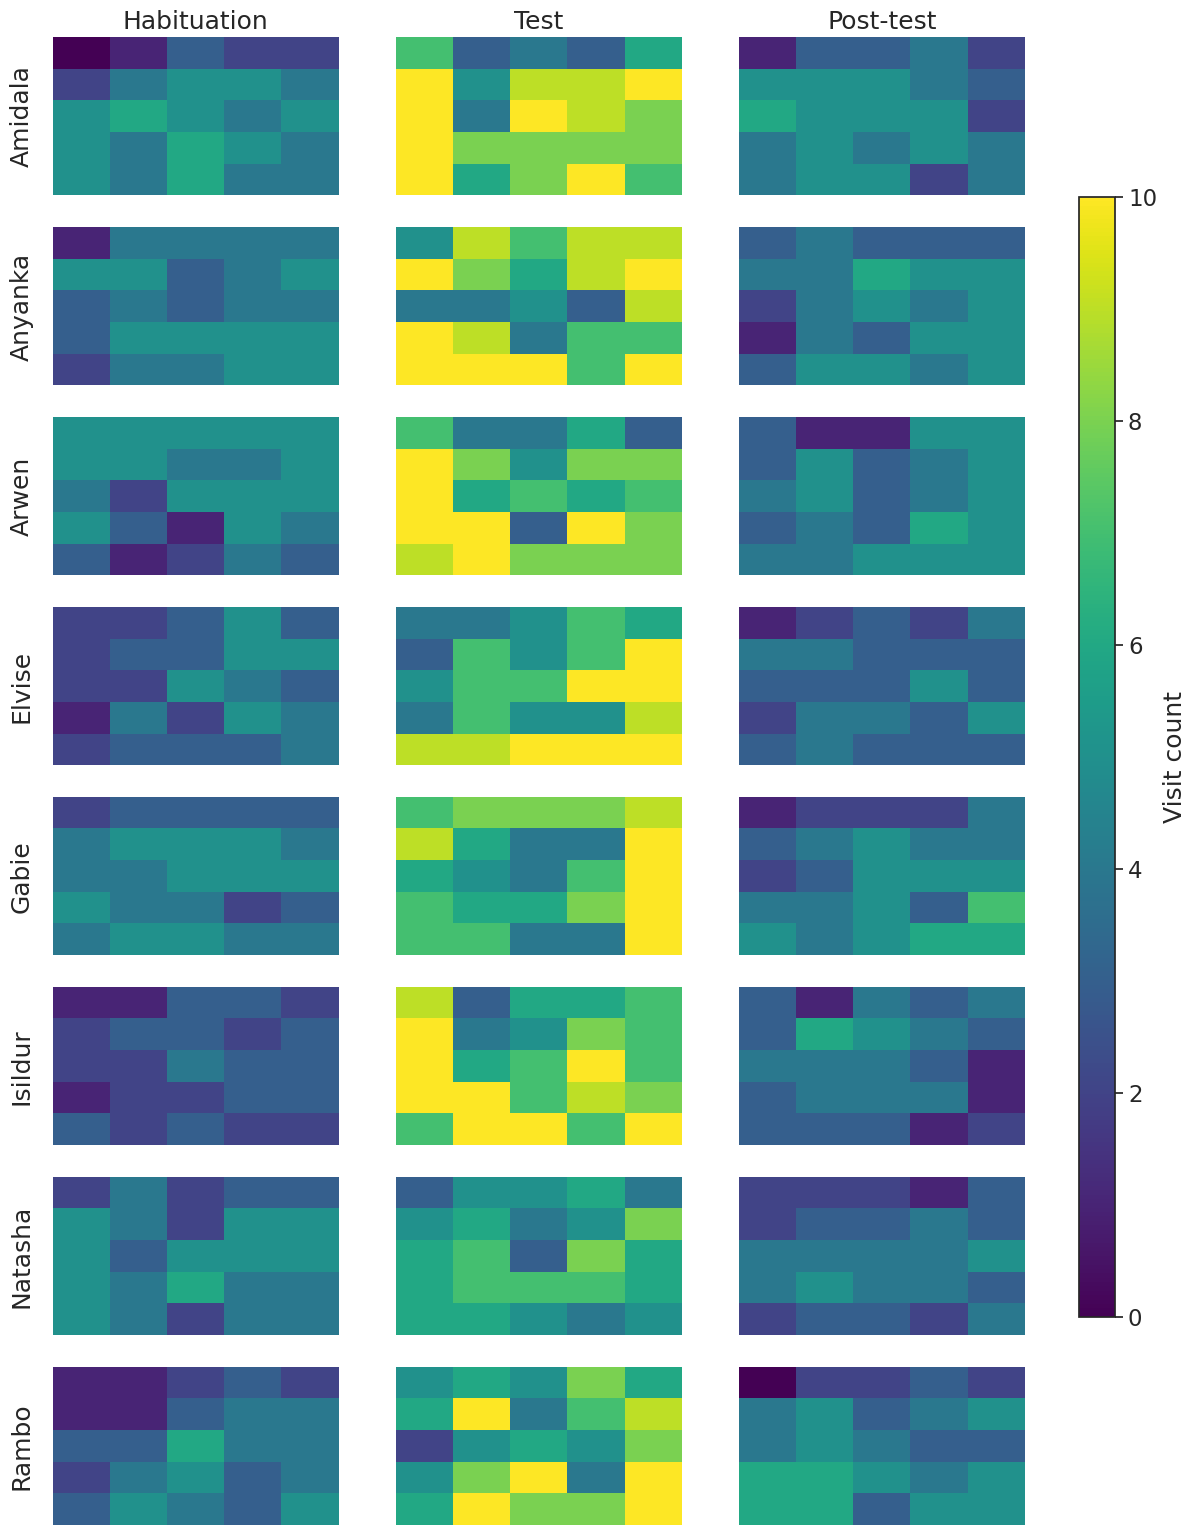

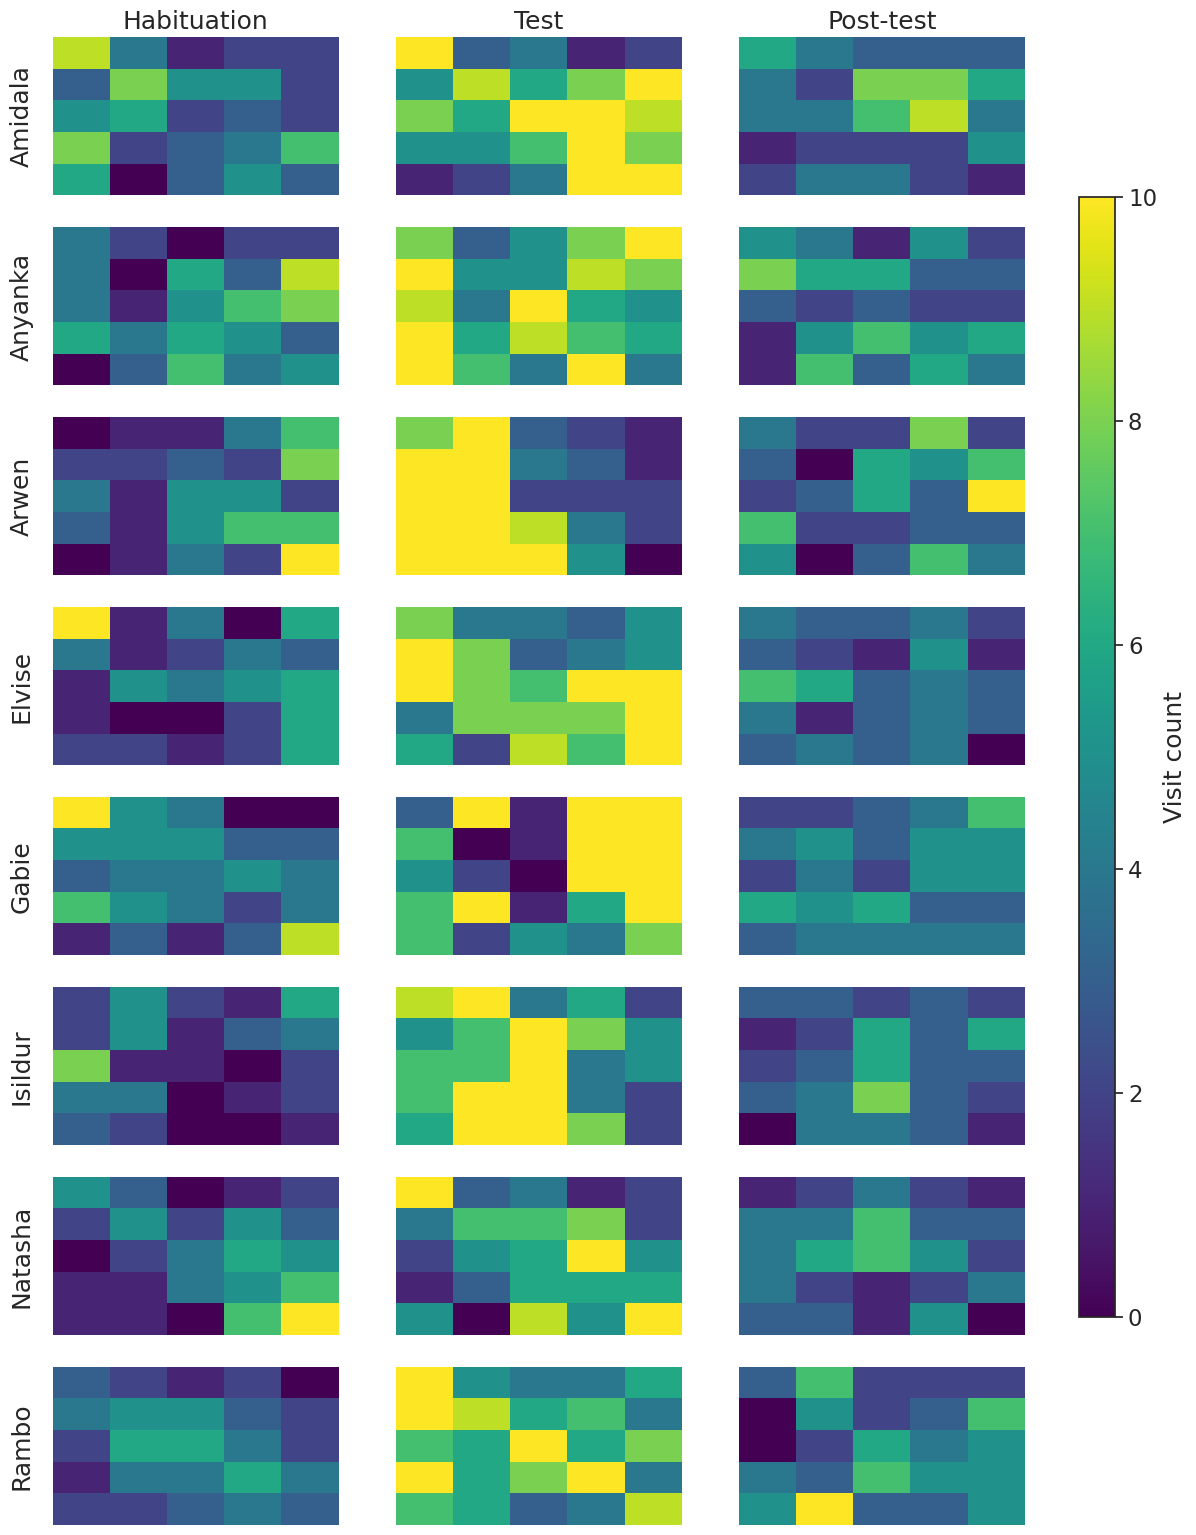

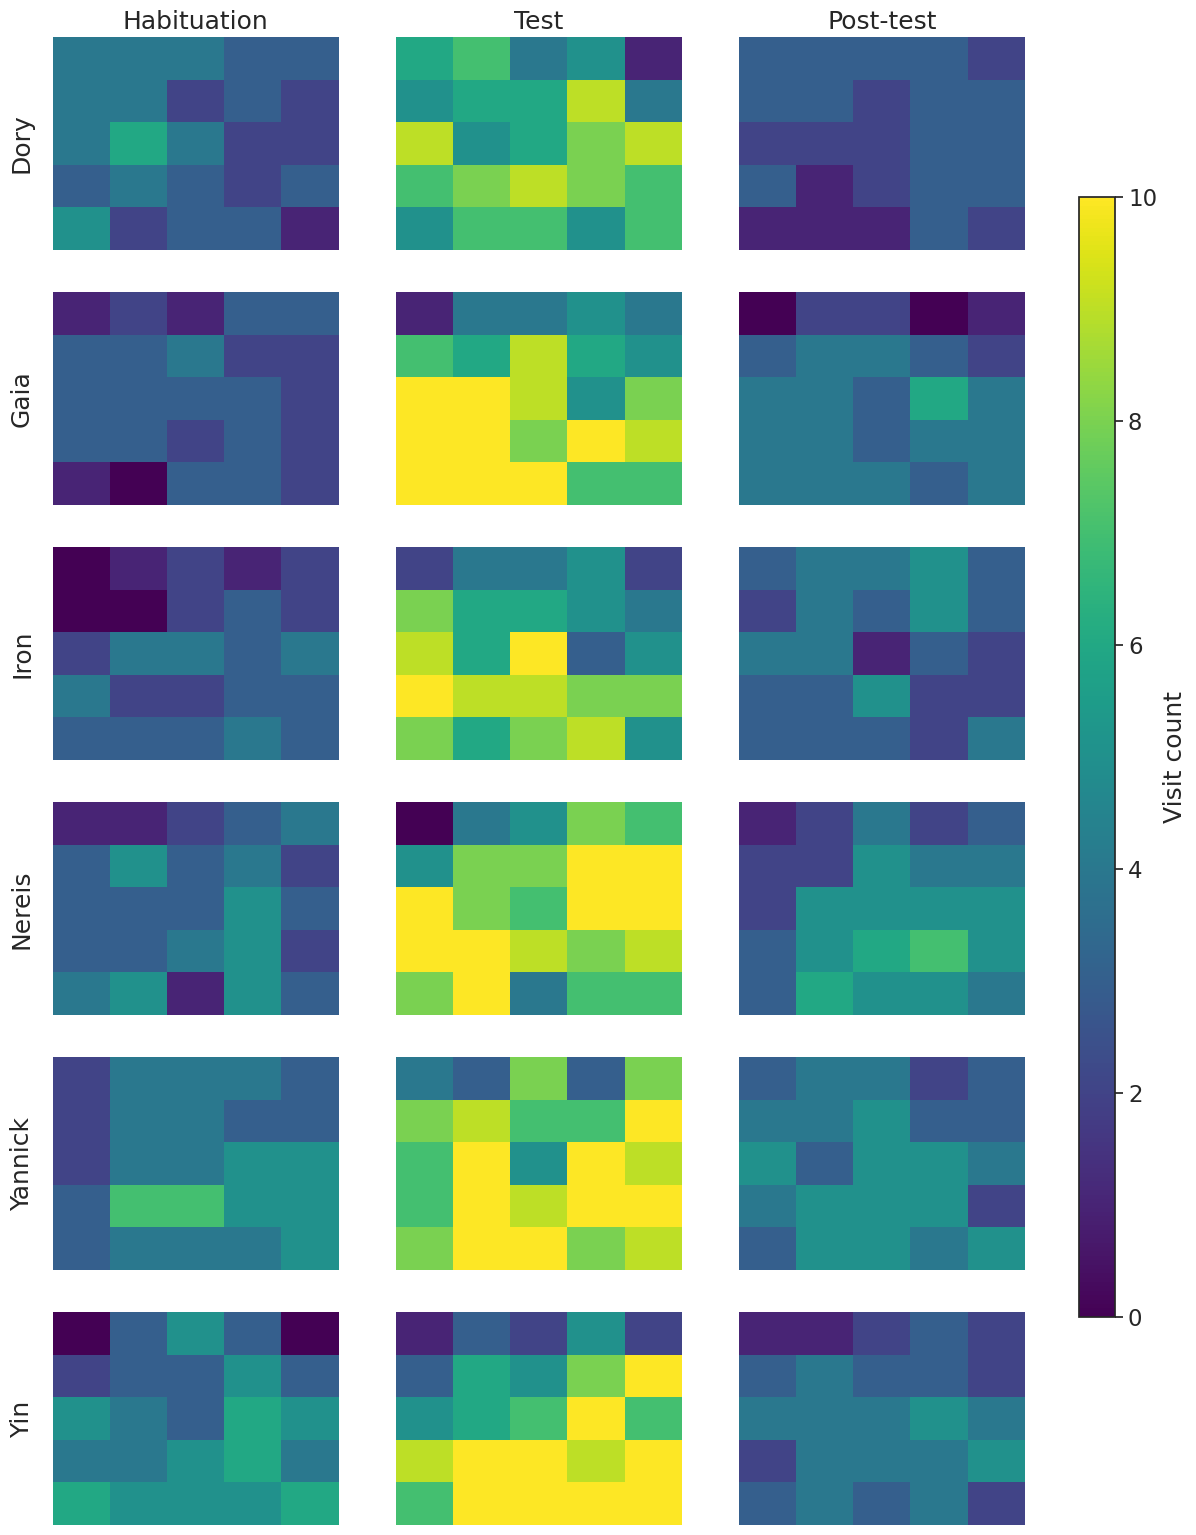

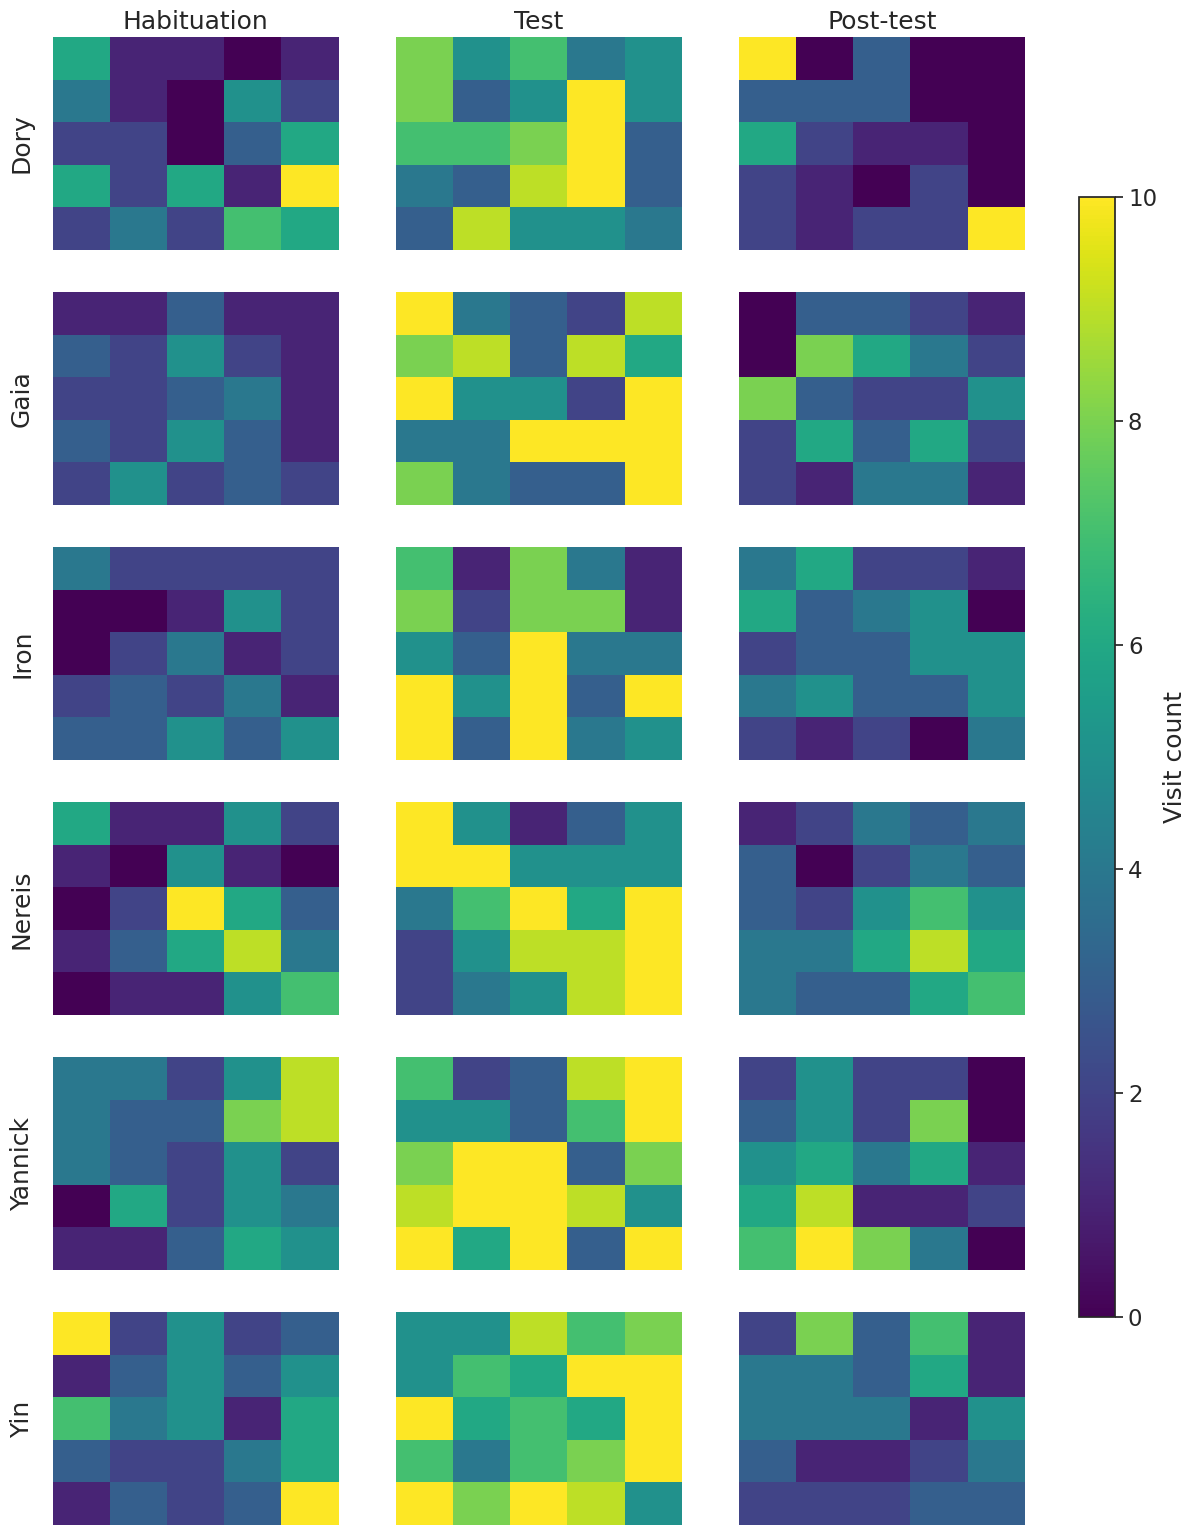

In [18]:
sns.set(style='white',font_scale=1.5)
for grp in compare_visit_map.groupby(['Species','type']):
    num_sub = len(grp[1]['Subject'].unique())
    rows,cols = num_sub, 3
    fig,ax = pl.subplots(rows,cols,figsize=(12,16))
    
    for i,sub in enumerate(grp[1].groupby('Subject')):
        for j,ph in enumerate(phase_order):
            sl = sub[1].loc[sub[1]['Phase']==ph].copy()
            hm = sns.heatmap(sl[sl.columns[:5]],annot=False, cbar=False, ax=ax[i][j], vmin=0,vmax=10,cmap='viridis')
    
            if i == 0:
                ax[i][j].set_title(phase_order[j])
            ax[i][j].set_xticklabels([])
            ax[i][j].set_yticklabels([])
        ax[i][0].set_ylabel(sub[0])
        mappable = hm.collections[0]

    cbar_ax = fig.add_axes([0.915, 0.15, 0.03, 0.7])

    fig.colorbar(
        mappable,
        cax=cbar_ax,
        label="Visit count"
    )        
#     pl.tight_layout()
    fig.subplots_adjust(right=0.87,top=0.95,left=0.06,bottom=0.02)
    fig.savefig(fig_dir+"Visit_heat_map_"+grp[0][0]+"_"+grp[0][1]+ps+".png")
    
    

In [19]:
sl[sl.columns[:5]]

,1,2,3,4,5
1,2.0,8.0,3.0,7.0,1.0
2,4.0,4.0,3.0,6.0,1.0
3,4.0,4.0,4.0,1.0,5.0
4,3.0,1.0,1.0,2.0,4.0
5,2.0,2.0,2.0,3.0,3.0


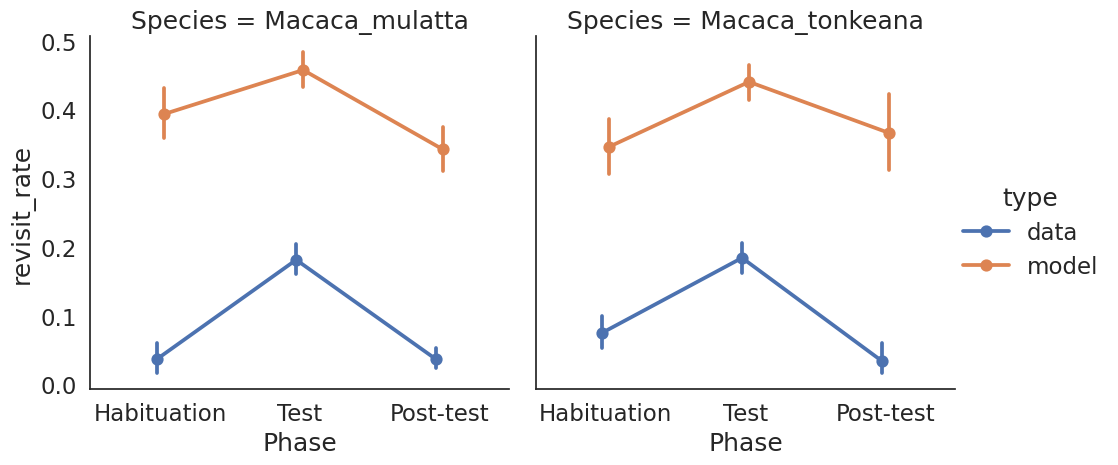

In [20]:
sns.catplot(x="Phase",col='Species',y="revisit_rate",hue='type',data=compare_stats,kind='point',dodge=True,order=phase_order)

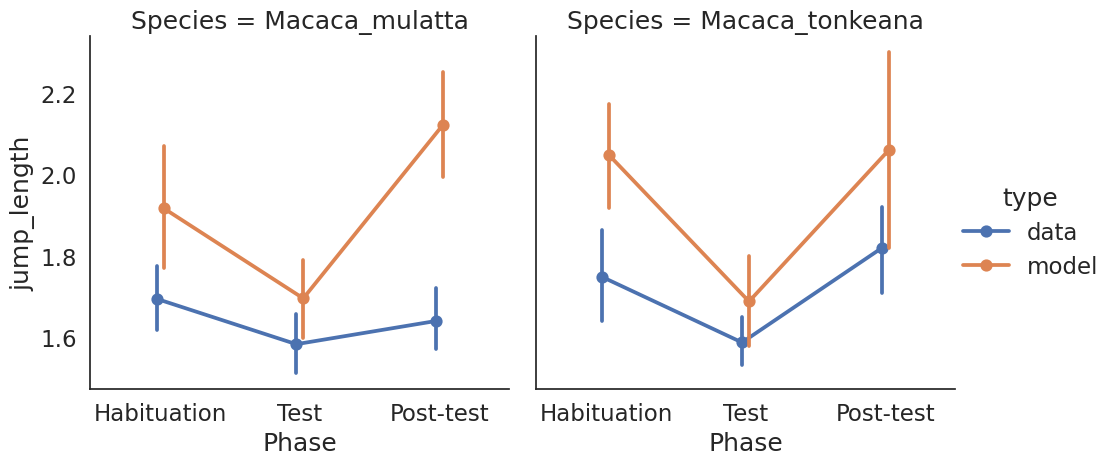

In [21]:
sns.catplot(x="Phase",col='Species',y="jump_length",hue='type',data=compare_stats,kind='point',dodge=True,order=phase_order)

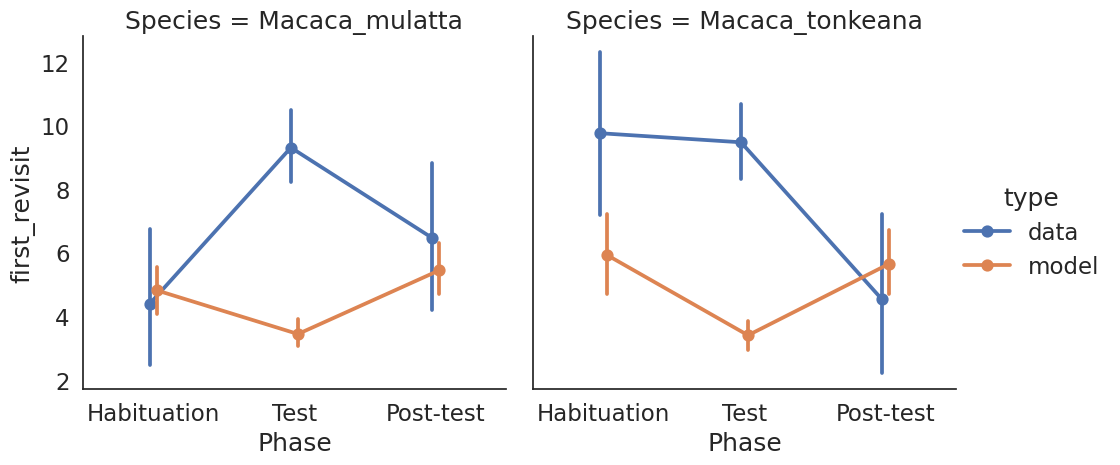

In [22]:
sns.catplot(x="Phase",col='Species',y="first_revisit",hue='type',data=compare_stats,kind='point',dodge=True,order=phase_order)

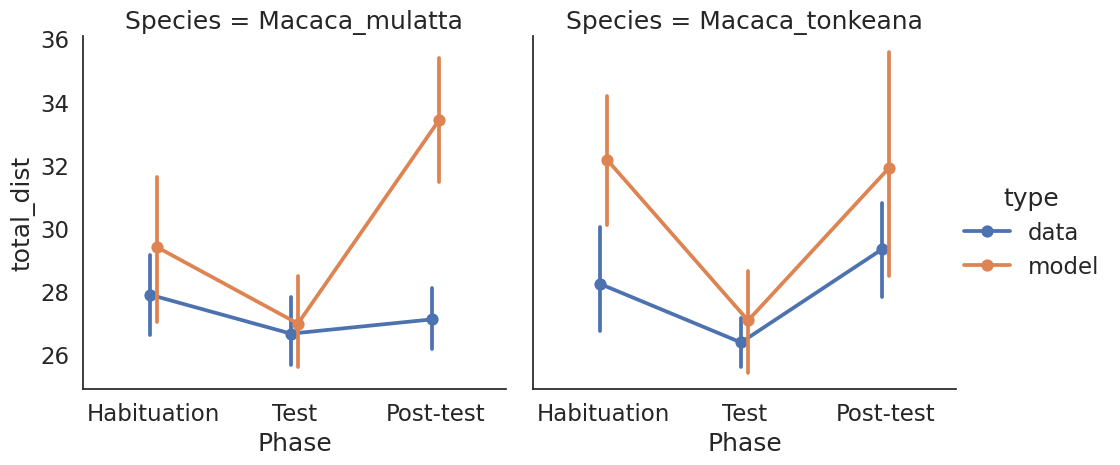

In [23]:
sns.catplot(x="Phase",col='Species',y="total_dist",hue='type',data=compare_stats,kind='point',dodge=True,order=phase_order)

In [24]:
to_plot = fittings.melt(id_vars=['Subject','Species','Phase','spatial_bias','LL'])
to_plot

,Subject,Species,Phase,spatial_bias,LL,variable,value
0,Amidala,Macaca_mulatta,Habituation,spiral,250.204557,Unnamed: 0,0.000000
1,Amidala,Macaca_mulatta,Post-test,row_scan,231.067153,Unnamed: 0,0.000000
2,Amidala,Macaca_mulatta,Test,spiral,477.440520,Unnamed: 0,0.000000
3,Anyanka,Macaca_mulatta,Habituation,row_scan,215.758630,Unnamed: 0,0.000000
4,Anyanka,Macaca_mulatta,Post-test,row_scan,222.651386,Unnamed: 0,0.000000
...,...,...,...,...,...,...,...
247,Yannick,Macaca_tonkeana,Post-test,column_scan,199.868389,beta,18.004914
248,Yannick,Macaca_tonkeana,Test,column_scan,465.828151,beta,2.623605
249,Yin,Macaca_tonkeana,Habituation,spiral,248.220851,beta,4.400619
250,Yin,Macaca_tonkeana,Post-test,row_scan,188.601759,beta,5.724026


In [25]:
to_plot = to_plot.loc[~to_plot['variable'].str.contains('Unnamed')]


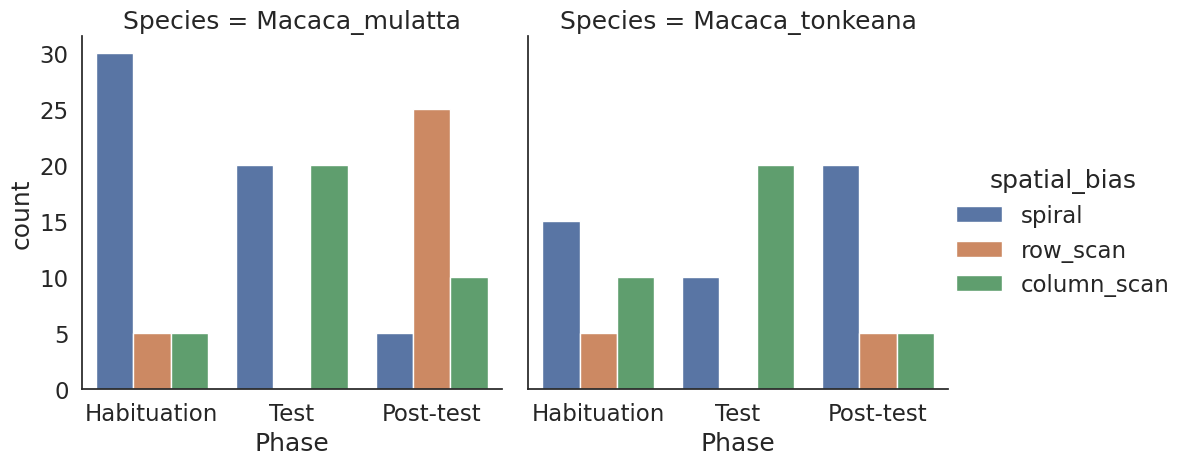

In [26]:
g1 = sns.catplot(x="Phase",hue="spatial_bias",col='Species',kind='count',data=to_plot.loc[~to_plot['variable'].str.contains('Unnamed')],order=phase_order)
g1.savefig(fig_dir+"spatial_strategies_"+ps+".png")

In [27]:
to_plot

,Subject,Species,Phase,spatial_bias,LL,variable,value
42,Amidala,Macaca_mulatta,Habituation,spiral,250.204557,W(spatial_bias),2.669023
43,Amidala,Macaca_mulatta,Post-test,row_scan,231.067153,W(spatial_bias),1.745463
44,Amidala,Macaca_mulatta,Test,spiral,477.440520,W(spatial_bias),6.756703
45,Anyanka,Macaca_mulatta,Habituation,row_scan,215.758630,W(spatial_bias),0.621562
46,Anyanka,Macaca_mulatta,Post-test,row_scan,222.651386,W(spatial_bias),1.922201
...,...,...,...,...,...,...,...
247,Yannick,Macaca_tonkeana,Post-test,column_scan,199.868389,beta,18.004914
248,Yannick,Macaca_tonkeana,Test,column_scan,465.828151,beta,2.623605
249,Yin,Macaca_tonkeana,Habituation,spiral,248.220851,beta,4.400619
250,Yin,Macaca_tonkeana,Post-test,row_scan,188.601759,beta,5.724026


In [28]:
compare_stats

,revisit_rate,traj_num,jump_length,first_revisit,total_dist,type,Subject,Phase,Species
0,0.00,0,1.631579,0,25.883627,data,Amidala,Habituation,Macaca_mulatta
1,0.10,1,1.894737,14,29.963990,data,Amidala,Habituation,Macaca_mulatta
2,0.05,2,2.000000,15,31.896819,data,Amidala,Habituation,Macaca_mulatta
3,0.10,3,2.105263,7,34.712101,data,Amidala,Habituation,Macaca_mulatta
4,0.05,4,1.947368,19,31.491901,data,Amidala,Habituation,Macaca_mulatta
...,...,...,...,...,...,...,...,...,...
5,0.35,5,1.894737,5,32.640986,model,Yin,Test,Macaca_tonkeana
6,0.25,6,2.210526,8,34.880951,model,Yin,Test,Macaca_tonkeana
7,0.30,7,2.052632,4,33.326901,model,Yin,Test,Macaca_tonkeana
8,0.40,8,1.947368,3,32.334010,model,Yin,Test,Macaca_tonkeana


In [29]:
stats_melt = compare_stats.melt(id_vars=['Subject','Species','Phase','type','traj_num'])

<Figure size 640x480 with 0 Axes>

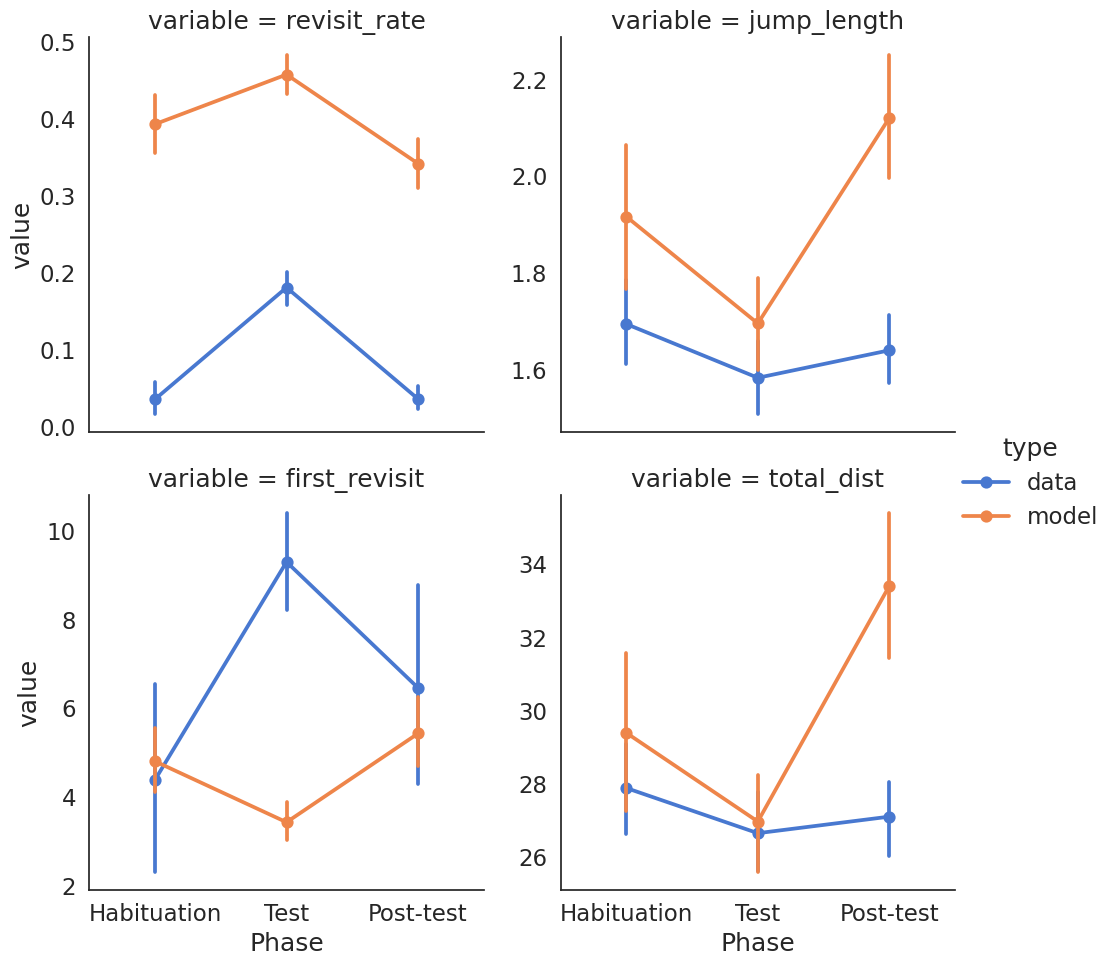

<Figure size 640x480 with 0 Axes>

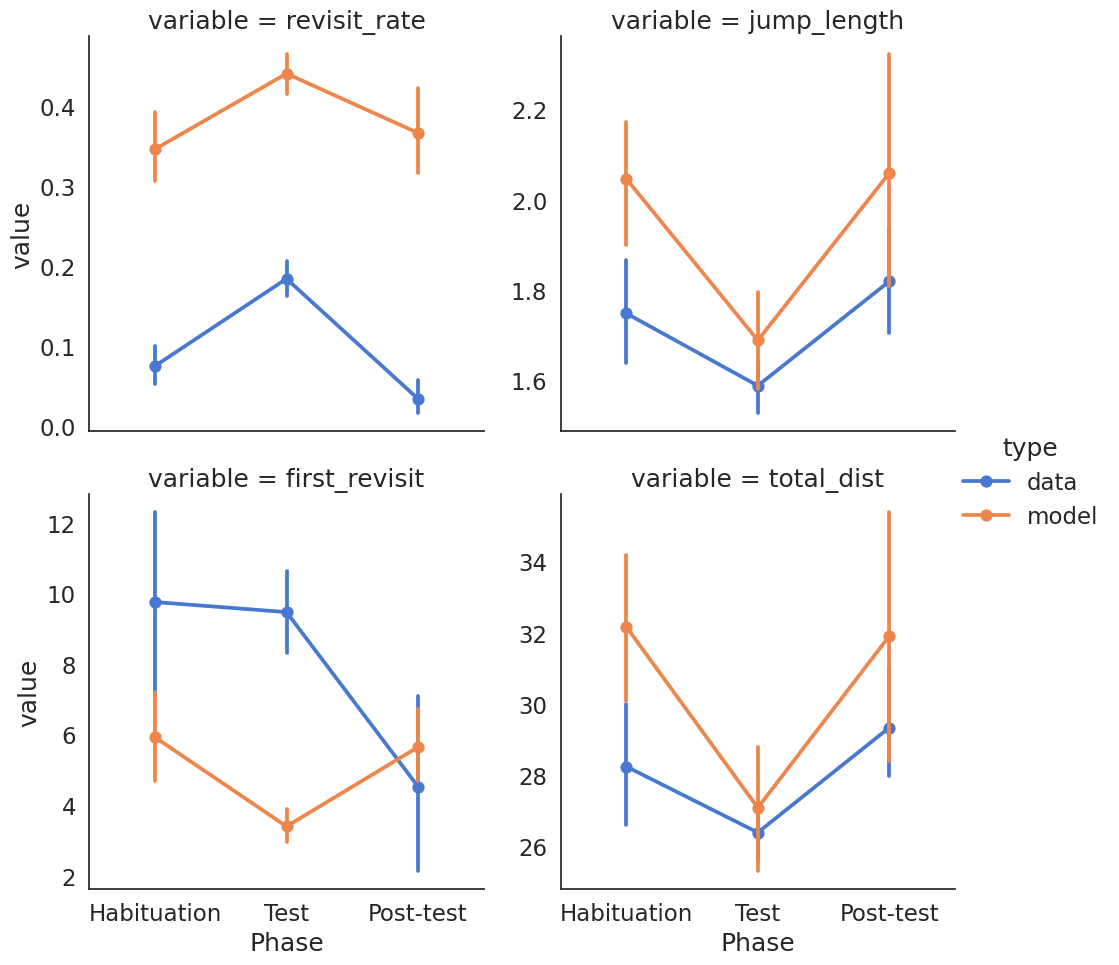

In [30]:
for grp in stats_melt.groupby('Species'):
    pl.figure()
    g1 = sns.catplot(x="Phase",y='value',hue='type',kind='point',col='variable',col_wrap=2,data=grp[1],sharey=False,palette='muted',order=phase_order)
    g1.savefig(fig_dir+"stats_compare_data_model_"+grp[0]+ps+".png")

In [31]:
# to_plot = fittings.melt(id_vars=['Subject','Species','Phase','spatial_bias','LL'])
# to_plot

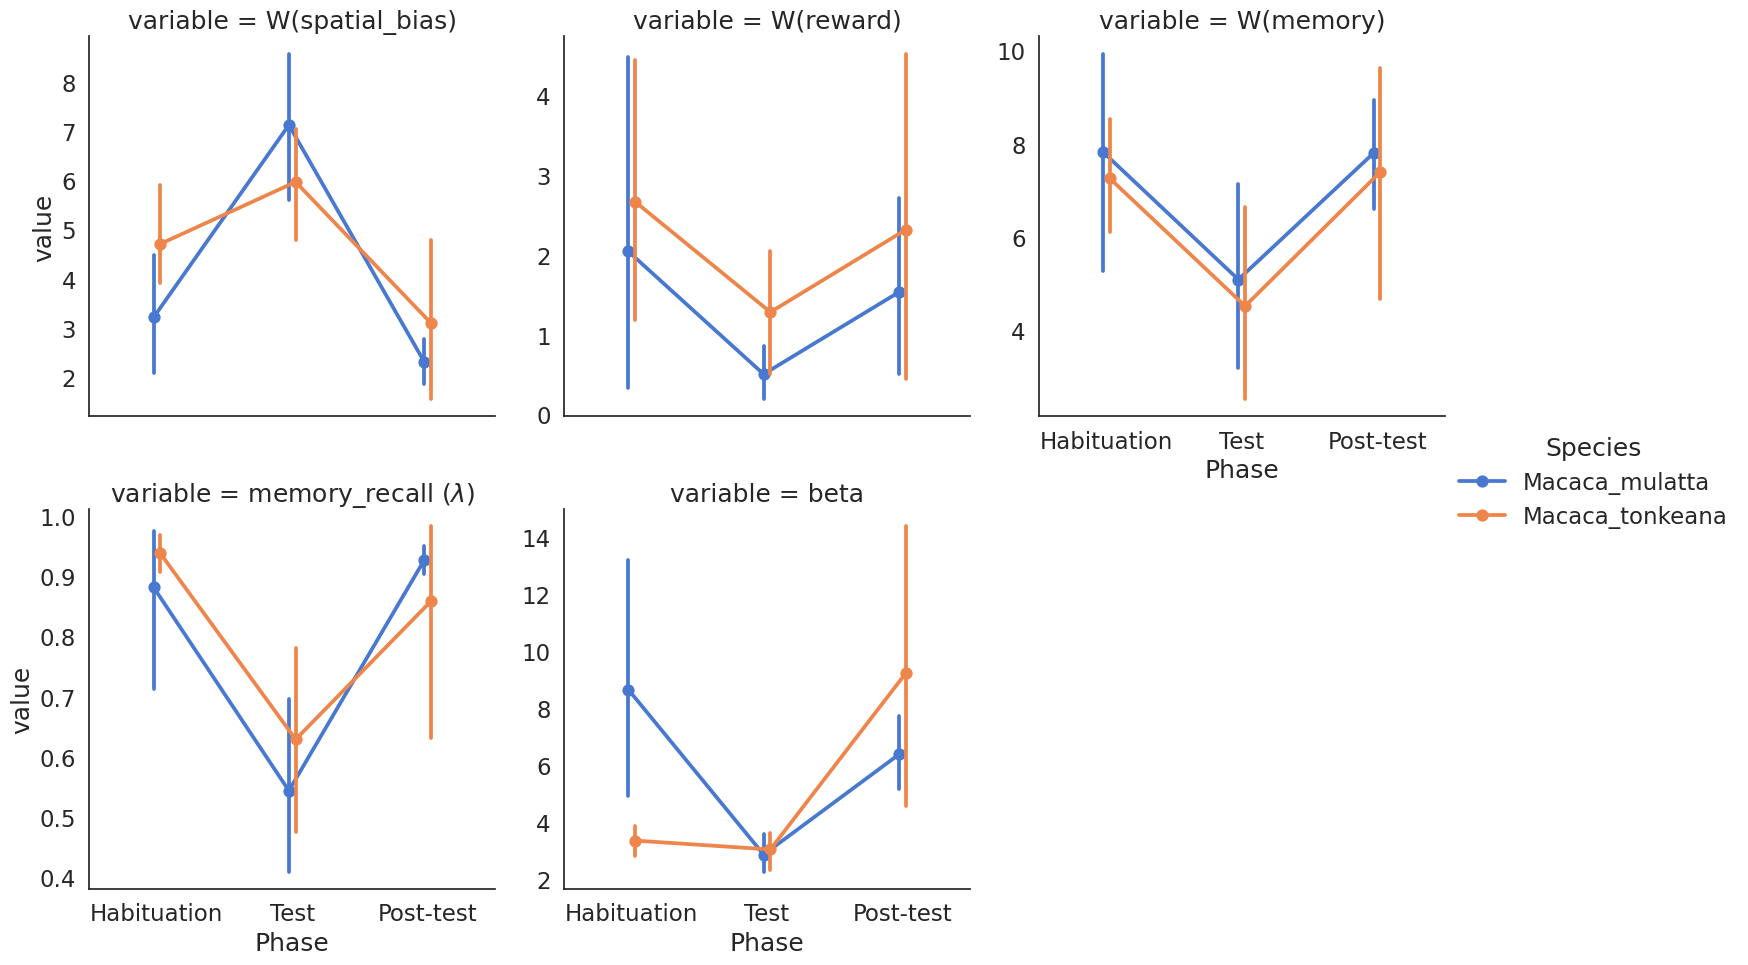

In [32]:
g1 = sns.catplot(x="Phase",y="value",hue='Species',data=to_plot,kind='point',dodge=True,col='variable',col_wrap=3,sharey=False,order=phase_order,palette='muted')

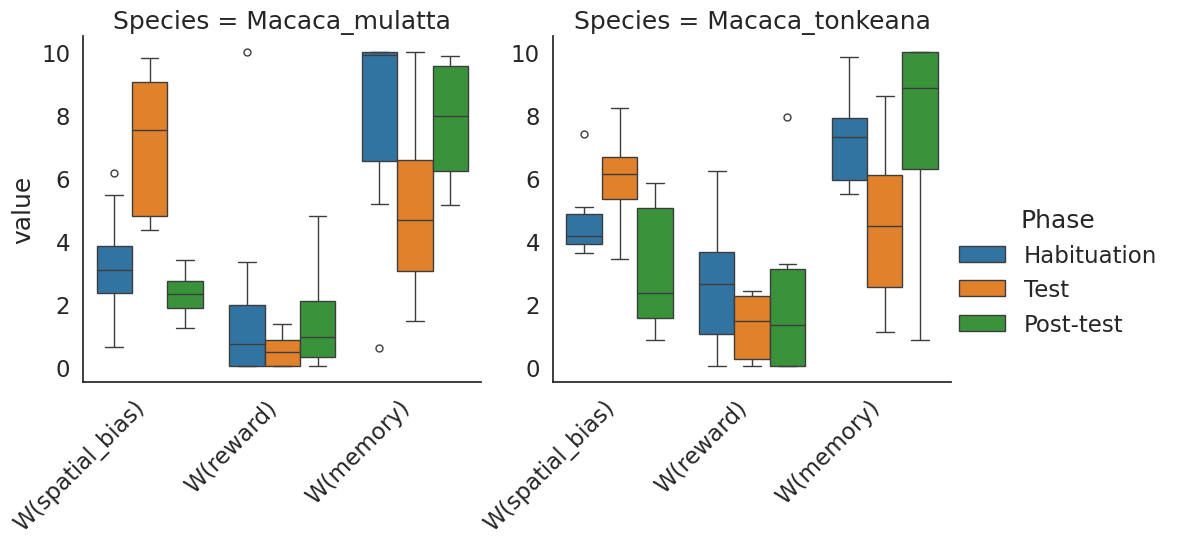

In [33]:
g1 = sns.catplot(x="variable",y="value",col='Species',data=to_plot.loc[to_plot['variable'].str.contains('W')],kind='box',dodge=True,hue='Phase',col_wrap=2,sharey=False,palette='tab10',hue_order=phase_order)
for ax in g1.axes:
    for x in ax.get_xticklabels():
        x.set_rotation(45)
        x.set_ha('right')
    ax.set_xlabel("")
g1.figure.subplots_adjust(bottom=0.2)
g1.savefig(fig_dir+"comparison_weights_"+ps+".png")

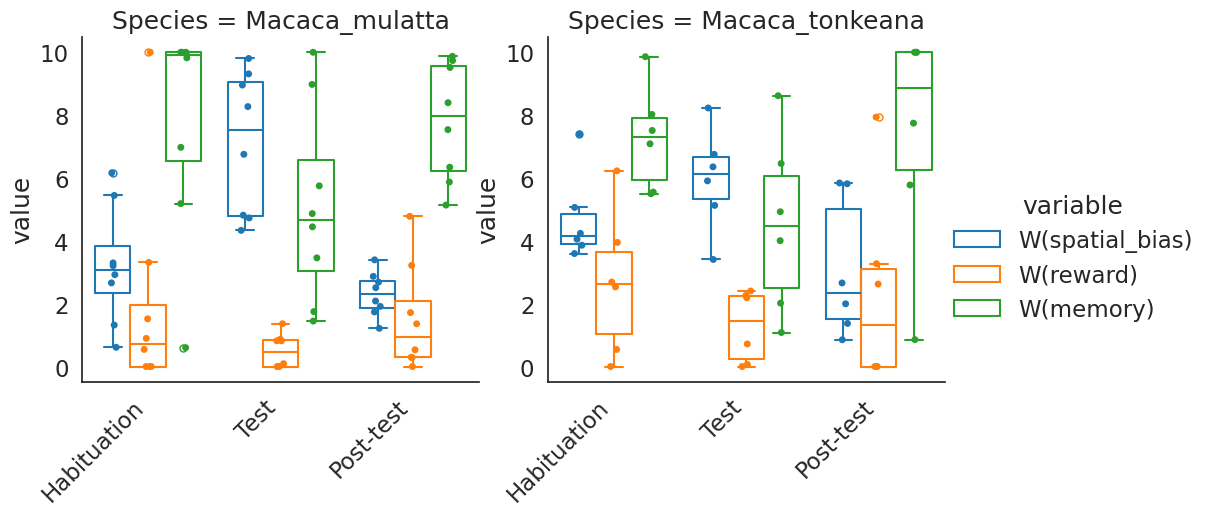

In [34]:
weights_df = to_plot.loc[to_plot['variable'].str.contains('W')].copy()
g1 = sns.catplot(x="Phase",y="value",col='Species',data=weights_df,kind='box',dodge=True,hue='variable',col_wrap=2,sharey=False,palette='tab10',order=phase_order,fill=False)
for ax in g1.axes:
    for x in ax.get_xticklabels():
        x.set_rotation(45)
        x.set_ha('right')
    ax.set_xlabel("")
    tit = ax.get_title().split(' = ')[1]
    sub = weights_df.loc[weights_df['Species']==tit].copy()
    sns.stripplot(ax=ax,data=sub,x="Phase",y='value',hue='variable',palette='tab10',order=phase_order,dodge=True,legend=False)
    ax.set_xlabel("")
g1.figure.subplots_adjust(bottom=0.2)
g1.savefig(fig_dir+"comparison_weights_with_points_"+ps+".png")

Macaca_mulatta
Macaca_tonkeana


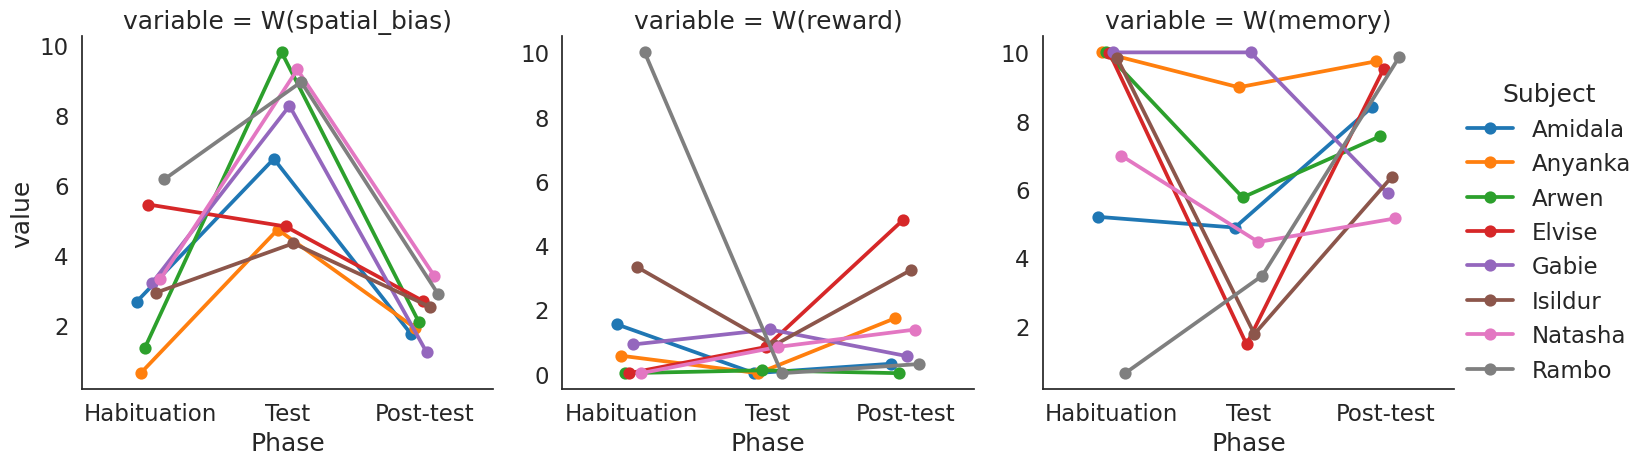

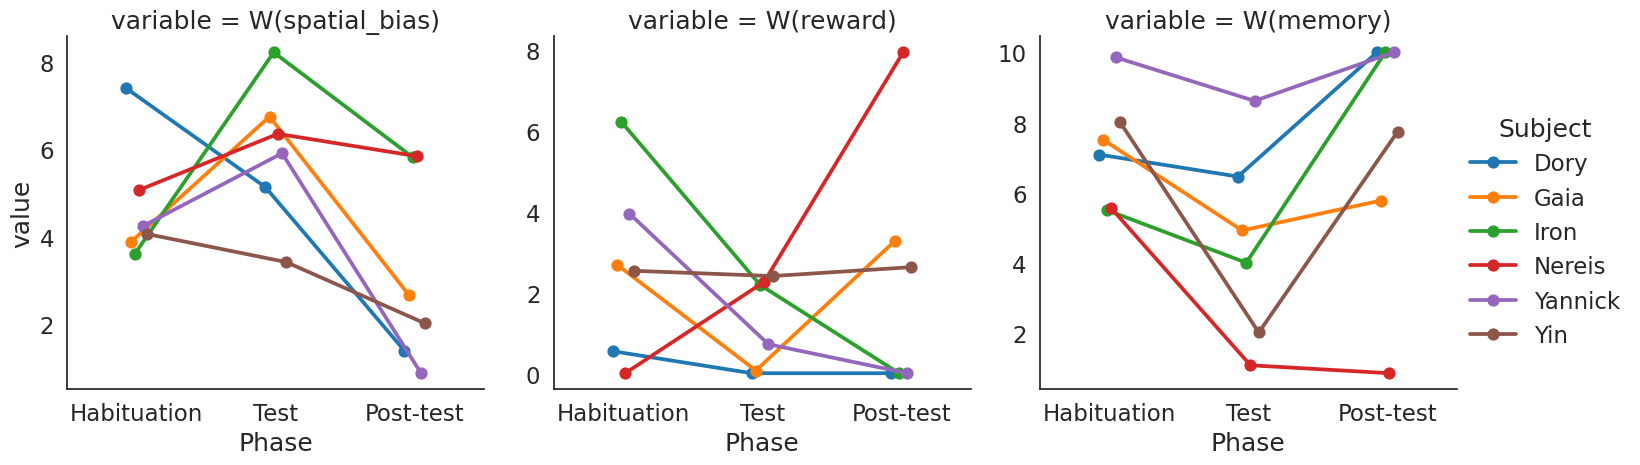

In [57]:
for grp in weights_df.groupby('Species'):
    print(grp[0])
    g1 = sns.catplot(x="Phase",y="value",col='variable',data=grp[1],kind='point',dodge=True,hue='Subject',col_wrap=3,sharey=False,palette='tab10',order=phase_order)
    g1.figure.savefig(fig_dir+"animal_wise_weights_"+grp[0]+".png")

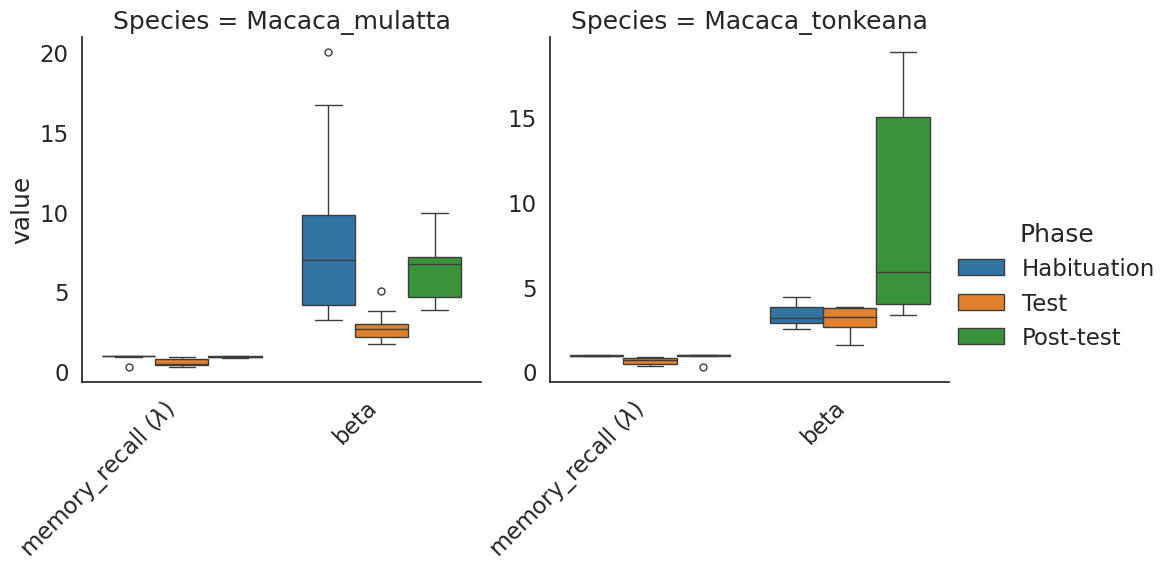

In [35]:
g1 = sns.catplot(x="variable",y="value",col='Species',data=to_plot.loc[~to_plot['variable'].str.contains('W')],kind='box',dodge=True,hue='Phase',col_wrap=2,sharey=False,palette='tab10',hue_order=phase_order)
for ax in g1.axes:
    for x in ax.get_xticklabels():
        x.set_rotation(45)
        x.set_ha('right')
    ax.set_xlabel("")
g1.figure.subplots_adjust(bottom=0.2)
g1.savefig(fig_dir+"comparison_other_params_"+ps+".png")

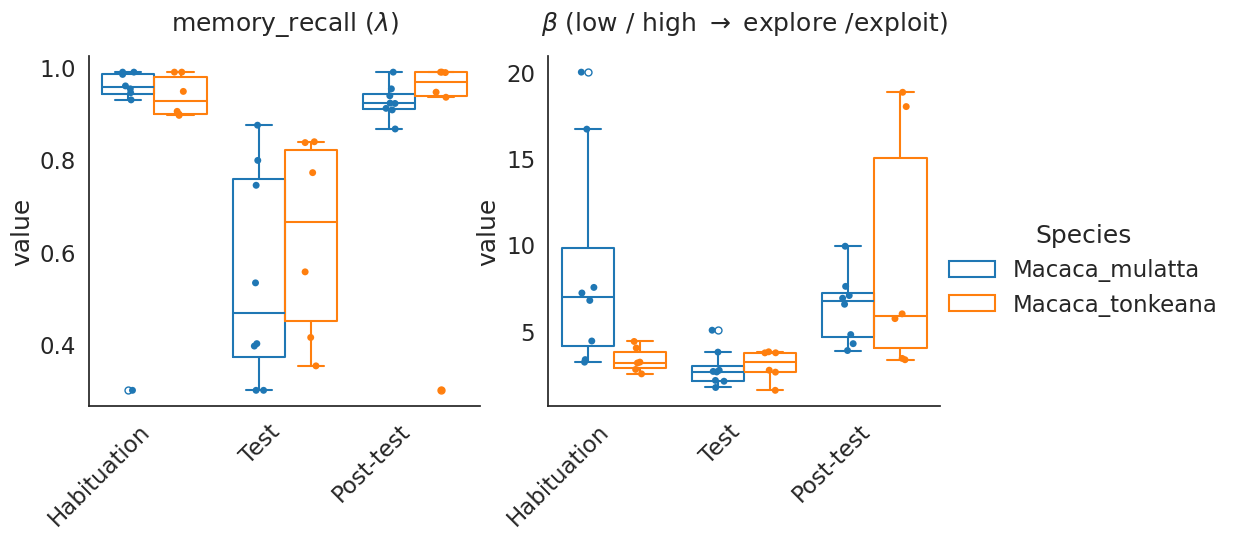

In [36]:
other_pars = to_plot.loc[~to_plot['variable'].str.contains('W')]
g1 = sns.catplot(x="Phase",y="value",col='variable',data=other_pars,kind='box',dodge=True,hue='Species',col_wrap=2,sharey=False,palette='tab10',order=phase_order,fill=False)
for ax in g1.axes:
    for x in ax.get_xticklabels():
        x.set_rotation(45)
        x.set_ha('right')
    ax.set_xlabel("")
    tit = ax.get_title().split(' = ')[1]
    sub = other_pars.loc[other_pars['variable']==tit].copy()
    sns.stripplot(ax=ax,data=sub,x="Phase",y='value',hue='Species',palette='tab10',order=phase_order,dodge=True,legend=False)
    
    if tit == 'beta':
        tit = r'$\beta$'+' (low / high '+r'$\rightarrow$'+' explore /exploit)'
    ax.set_title(tit,y=1.05)
    ax.set_xlabel("")
g1.figure.subplots_adjust(bottom=0.2,top=0.9)
g1.savefig(fig_dir+"comparison_other_params_with_points_"+ps+".png")

Macaca_mulatta
Macaca_tonkeana


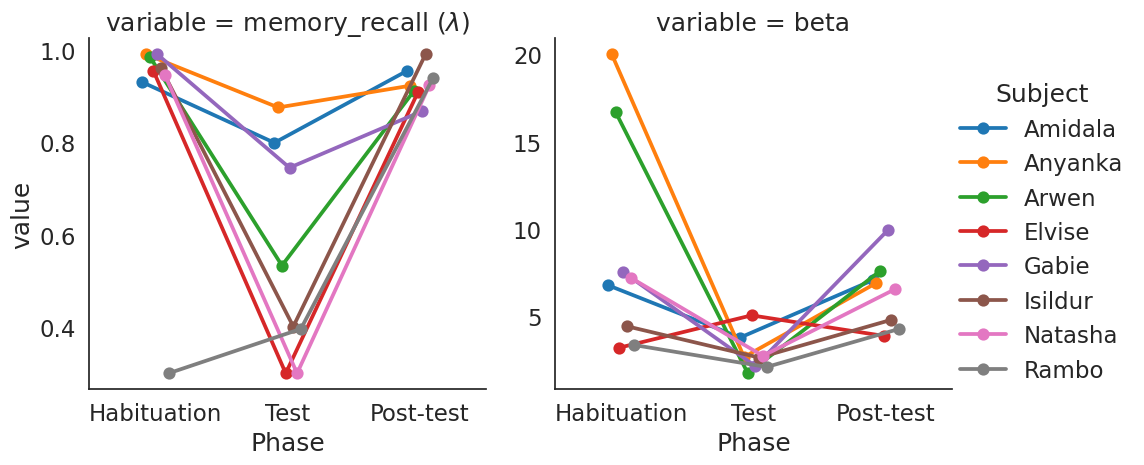

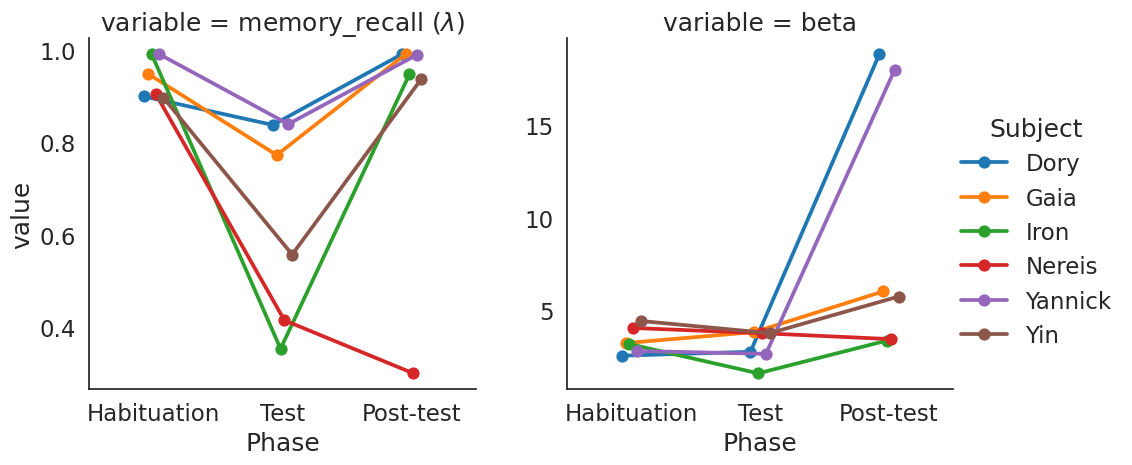

In [56]:
for grp in other_pars.groupby('Species'):
    print(grp[0])
    g1 = sns.catplot(x="Phase",y="value",col='variable',data=grp[1],kind='point',dodge=True,hue='Subject',col_wrap=2,sharey=False,palette='tab10',order=phase_order)
    g1.figure.savefig(fig_dir+"animal_wise_other_pars_"+grp[0]+".png")

/tmp/ipykernel_2446872/2907018700.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g1 = sns.catplot(x="Phase",y="dist_traj(model,data)",col='Species',data=compare_dist_trajs,kind='box',dodge=True,col_wrap=2,sharey=False,palette='tab10',order=phase_order)


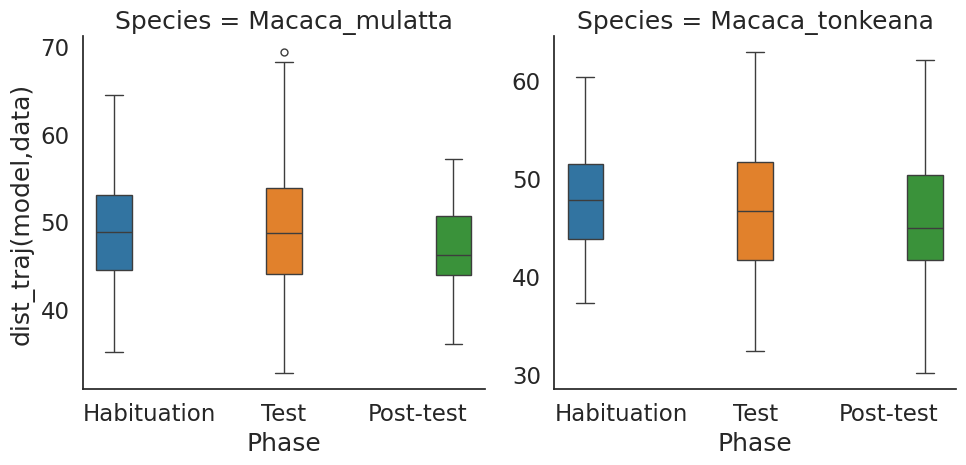

In [37]:
g1 = sns.catplot(x="Phase",y="dist_traj(model,data)",col='Species',data=compare_dist_trajs,kind='box',dodge=True,col_wrap=2,sharey=False,palette='tab10',order=phase_order)
g1.savefig(fig_dir+"distance_between_trajectories_"+ps+".png")

In [38]:
compare_trajs

,Rows_model,Cols_model,Rows_data,Cols_data,Trials,Subject,Phase,Species,spatial_bias
0,1,3,1,3,0,Amidala,Habituation,Macaca_mulatta,spiral
1,0,0,2,4,0,Amidala,Habituation,Macaca_mulatta,spiral
2,2,0,1,4,0,Amidala,Habituation,Macaca_mulatta,spiral
3,4,3,4,3,0,Amidala,Habituation,Macaca_mulatta,spiral
4,2,0,4,2,0,Amidala,Habituation,Macaca_mulatta,spiral
...,...,...,...,...,...,...,...,...,...
195,4,2,4,3,9,Yin,Test,Macaca_tonkeana,column_scan
196,4,2,2,2,9,Yin,Test,Macaca_tonkeana,column_scan
197,3,2,3,4,9,Yin,Test,Macaca_tonkeana,column_scan
198,3,2,4,4,9,Yin,Test,Macaca_tonkeana,column_scan


In [39]:
def plot_mean_trajectories(df):



    for (subj, phase), grp in df.groupby(["Subject","Phase"]):

        fig, ax = plt.subplots(figsize=(6,6))

        starts = sorted({
            tuple(traj[0]) for traj in grp["Trajectory"]
        })

        color_dict = {
            s: colors[i]
            for i,s in enumerate(starts)
        }

        for start in starts:

            actual = grp[
                (grp.type=="Actual") &
                (grp.Trajectory.apply(lambda x: tuple(x[0])==start))
            ]

            sims = grp[
                (grp.type=="Model") &
                (grp.Trajectory.apply(lambda x: tuple(x[0])==start))
            ]

            if len(actual)==0 or len(sims)==0:
                continue

            actual_traj = np.asarray(actual.iloc[0].Trajectory)

            sim_trajs = [
                np.asarray(t)
                for t in sims.Trajectory
            ]

            T = min(map(len, sim_trajs))
            T = min(T, len(actual_traj))

            sim_stack = np.stack(
                [t[:T] for t in sim_trajs],
                axis=0
            )

            mean_pos = sim_stack.mean(axis=0)
            std_pos = sim_stack.std(axis=0)

            c = color_dict[start]

            # actual
            ax.plot(
                actual_traj[:T,1],
                actual_traj[:T,0],
                '-',
                color=c,
                lw=3
            )

            # simulated mean
            ax.plot(
                mean_pos[:,1],
                mean_pos[:,0],
                '--',
                color=c,
                lw=2
            )

            # uncertainty every 3 steps
            for k in range(0,T,3):

                e = Ellipse(
                    (mean_pos[k,1], mean_pos[k,0]),
                    width=2*std_pos[k,1],
                    height=2*std_pos[k,0],
                    fill=False,
                    edgecolor=c,
                    alpha=.4
                )

                ax.add_patch(e)

        ax.set_xlim(-0.5,4.5)
        ax.set_ylim(4.5,-0.5)

        ax.set_xticks(range(5))
        ax.set_yticks(range(5))

        ax.grid(True)

        ax.set_title(f"{subj} : {phase}")

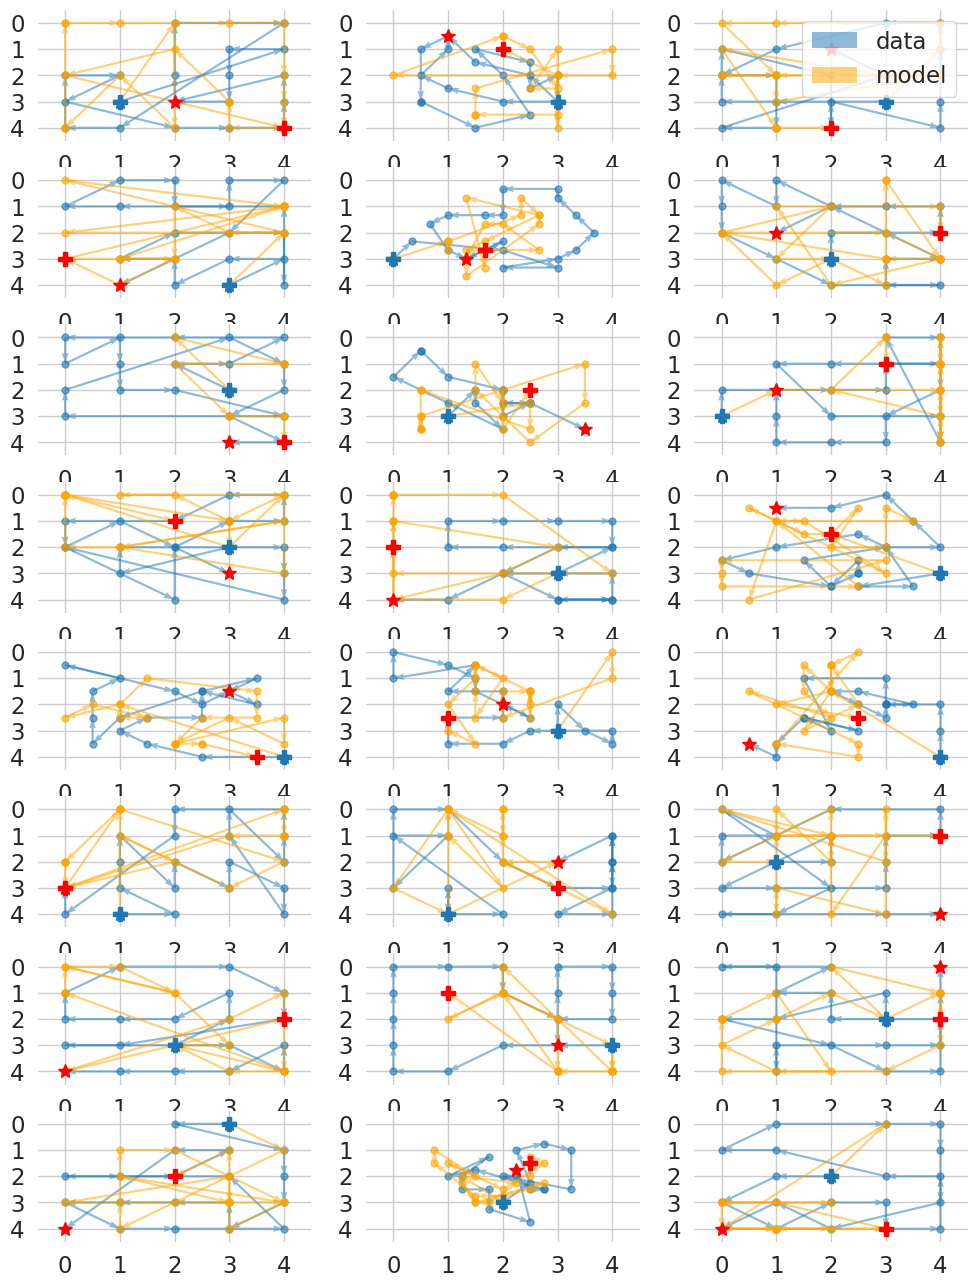

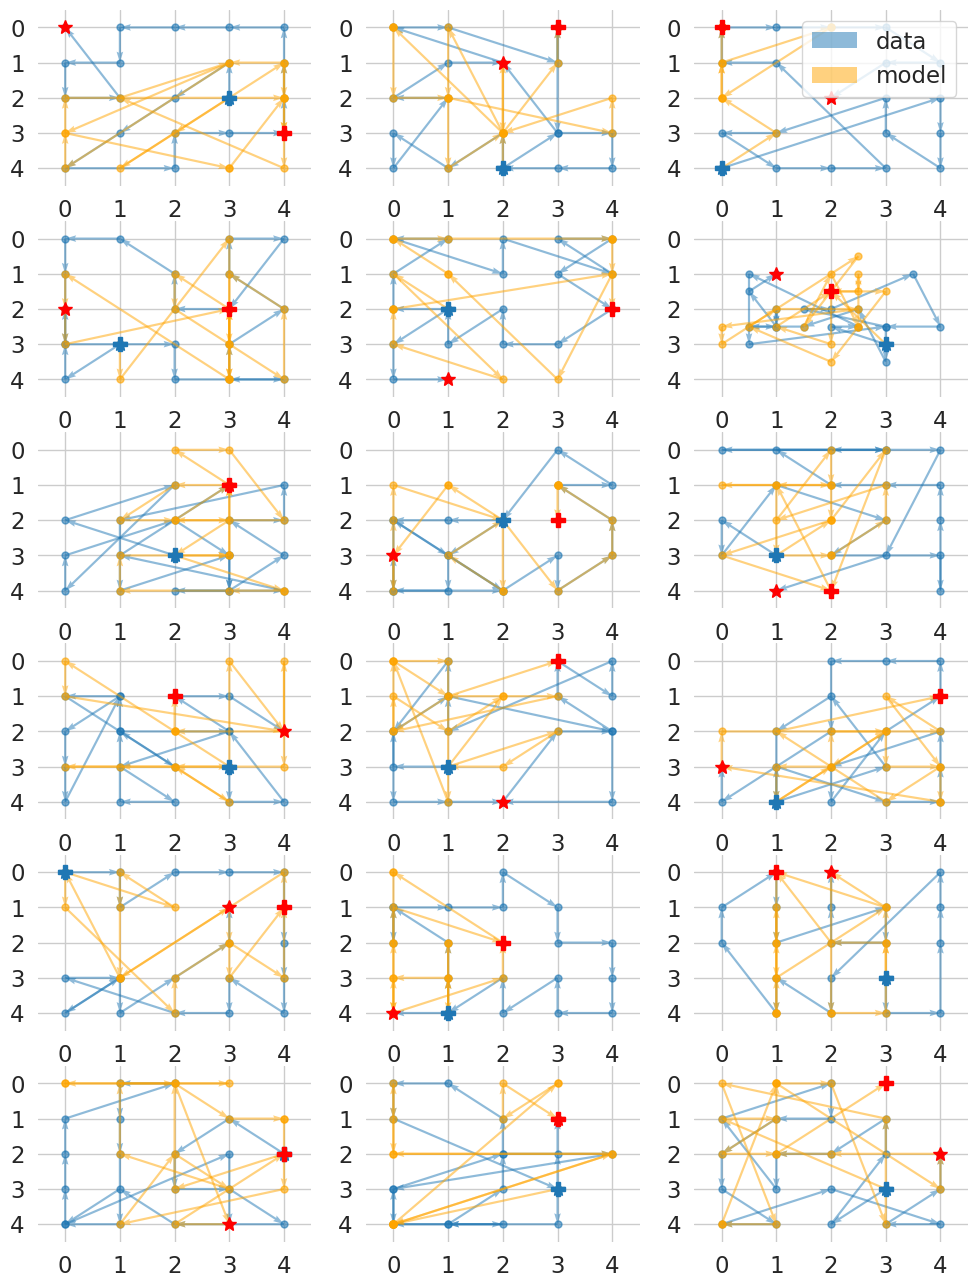

In [40]:
colors = sns.color_palette("tab20", 25)
for grp in compare_trajs.groupby('Species'):
    num_sub = len(grp[1]['Subject'].unique())
    rows,cols = num_sub, 3
    fig,ax = pl.subplots(rows,cols,figsize=(12,16))
    
    for i,sub in enumerate(grp[1].groupby('Subject')):
        for j,ph in enumerate(phase_order):
            sl = sub[1].loc[sub[1]['Phase']==ph].copy()
            sim_traj = [[[r,c] for r,c in zip(x[1]['Rows_model'],x[1]['Cols_model'])]  for x in sl.groupby('Trials')  ]
            dat_traj = [[[r,c] for r,c in zip(x[1]['Rows_data'],x[1]['Cols_data'])]  for x in sl.groupby('Trials')  ]
            
            starts_sim = sorted({tuple(traj1[0]) for traj1 in sim_traj})
            starts_dat = sorted({tuple(traj1[0]) for traj1 in dat_traj})
            
#             mean_traj_sim = np.mean(sim_traj,axis=0)
#             mean_traj_dat = np.mean(dat_traj,axis=0)
            
#             std_traj_sim = np.std(sim_traj,axis=0)
#             std_traj_dat = np.std(dat_traj,axis=0)
            
            
            color_dict = {s: colors[i]  for i,s in enumerate(starts_dat)}
            rand_idx = np.random.choice(len(starts_dat),1)
            for start in [starts_dat[rand_idx[0]]]:
                idx_sim_temp = np.where(np.logical_and(np.array(sim_traj)[:,:,0]==start[0],np.array(sim_traj)[:,:,1]==start[1]))
                idx_dat_temp = np.where(np.logical_and(np.array(dat_traj)[:,:,0]==start[0],np.array(dat_traj)[:,:,1]==start[1]))
                
                which_traj_sim = np.array(sim_traj)[idx_sim_temp[0][np.where(idx_sim_temp[1]==0)]]
                which_traj_dat = np.array(dat_traj)[idx_dat_temp[0][np.where(idx_dat_temp[1]==0)]]
                
                mean_traj_sim = np.mean(which_traj_sim,axis=0)
                mean_traj_dat = np.mean(which_traj_dat,axis=0)
                
                std_traj_sim = np.std(which_traj_sim,axis=0)
                std_traj_dat = np.std(which_traj_dat,axis=0)
                
                c = color_dict[start]
                
                y1 = mean_traj_dat[:,0]     # rows
                x1 = mean_traj_dat[:,1]     # cols

                # movement vectors
                dx1 = np.diff(x1)
                dy1 = np.diff(y1)                
#                 ax[i][j].plot(
#                     mean_traj_dat[:,1],
#                     mean_traj_dat[:,0],
#                     '-',
#                     color='dodgerblue',
#                     lw=3
#                 )
                ax[i][j].plot(x1[0],y1[0],marker='*',color='tab:blue',ms=10)
                ax[i][j].plot(x1[-1],y1[-1],marker='*',color='red',ms=10)
                ax[i][j].quiver(
                    x1[:-1],
                    y1[:-1],
                    dx1,
                    dy1,
                    angles='xy',
                    scale_units='xy',
                    scale=1,
                    width=0.008,
                    color='tab:blue',
                    alpha=0.5,label='data'
                )                

                ax[i][j].scatter(
                    x1, y1,
                    s=25,
                    color='tab:blue',
                    alpha=.6
                )        
                # simulated mean
#                 ax[i][j].plot(
#                     mean_traj_sim[:,1],
#                     mean_traj_sim[:,0],
#                     '--',
#                     color='b',
#                     lw=2
#                 )

                y2 = mean_traj_sim[:,0]     # rows
                x2 = mean_traj_sim[:,1]     # cols

                # movement vectors
                dx2 = np.diff(x2)
                dy2 = np.diff(y2)       

                ax[i][j].quiver(
                    x2[:-1],
                    y2[:-1],
                    dx2,
                    dy2,
                    angles='xy',
                    scale_units='xy',
                    scale=1,
                    width=0.008,
                    color='orange',
                    alpha=0.5,
                    label='model'
                )                       
                ax[i][j].scatter(
                    x2, y2,
                    s=25,
                    color='orange',
                    alpha=.6
                )        
                ax[i][j].plot(x2[0],y2[0],marker='P',color='tab:blue',ms=10)
                ax[i][j].plot(x2[-1],y2[-1],marker='P',color='red',ms=10)                
                if i == 0 and j == 2:
                    ax[i][j].legend(loc='upper right',bbox_to_anchor=(1.0,1.0))
                
#                 # uncertainty every 3 steps
#                 for k in range(0,T,3):

#                     e = Ellipse(
#                         (mean_pos[k,1], mean_pos[k,0]),
#                         width=2*std_pos[k,1],
#                         height=2*std_pos[k,0],
#                         fill=False,
#                         edgecolor=c,
#                         alpha=.4
#                     )

#                     ax.add_patch(e)                
                
            ax[i][j].set_xlim(-0.5,4.5)
            ax[i][j].set_ylim(4.5,-0.5)

            ax[i][j].set_xticks(range(5))
            ax[i][j].set_yticks(range(5))

            ax[i][j].grid(True)                
            for pos in ['top','right','bottom','left']:
                ax[i][j].spines[pos].set_visible(False)
                
            

        

In [ ]:
which_traj_sim

In [ ]:
starts_dat[rand_idx[0]]

In [ ]:
np.mean(sim_traj,axis=0)

In [ ]:
sim_traj

In [ ]:
starts_sim = sorted({tuple(traj1[0]) for traj1 in sim_traj})
starts_dat = sorted({tuple(traj1[0]) for traj1 in dat_traj})


In [ ]:
start = starts_dat[3]
start

In [ ]:
starts_dat

In [ ]:
idx = np.where(np.logical_and(np.array(sim_traj)[:,:,0]==start[0],np.array(sim_traj)[:,:,1]==start[1]))

In [ ]:
idx1 = idx[0][np.where(idx[1]==0)]

In [ ]:
idx1

In [ ]:
np.array(sim_traj)[idx1]

In [ ]:
np.array(sim_traj)[np.array([1])]

In [ ]:
np.mean([np.array(sim_traj)[idx1][0], np.array(sim_traj)[1]],axis=0)

In [ ]:
sim_traj

In [ ]:
BR = np.ones((5, 5))
BR = bmm.update_reward(BR,(2,2),1)
BR_norm = bmm.normalize(BR)
BR_norm

In [ ]:
sns.heatmap(BR_norm,cmap='viridis')